In [42]:
import os
import joblib
from core.predict_cancellation import process_data
import pandas
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.ensemble import IsolationForest

In [31]:
df = process_data(pathToData='./data/ncr_ride_bookings.csv')
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Ride Distance,Driver Ratings,Customer Rating,Payment Method,is_cancelled,hour,weekday,month,day,is_weekend
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,0,12,5,3,23,1
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,5.73,NaN,NaN,UPI,0,18,4,11,29,0
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,13.58,4.9,4.9,Debit Card,0,8,4,8,23,0
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,34.02,4.6,5.0,UPI,0,17,0,10,21,0
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,48.21,4.1,4.3,UPI,0,22,0,9,16,0


In [33]:
print('number of rows: ', df.shape[0])
print('number of columns: ', df.shape[1])
print('number of missing values: ', df.isnull().sum())

number of rows:  150000
number of columns:  27
number of missing values:  Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
is

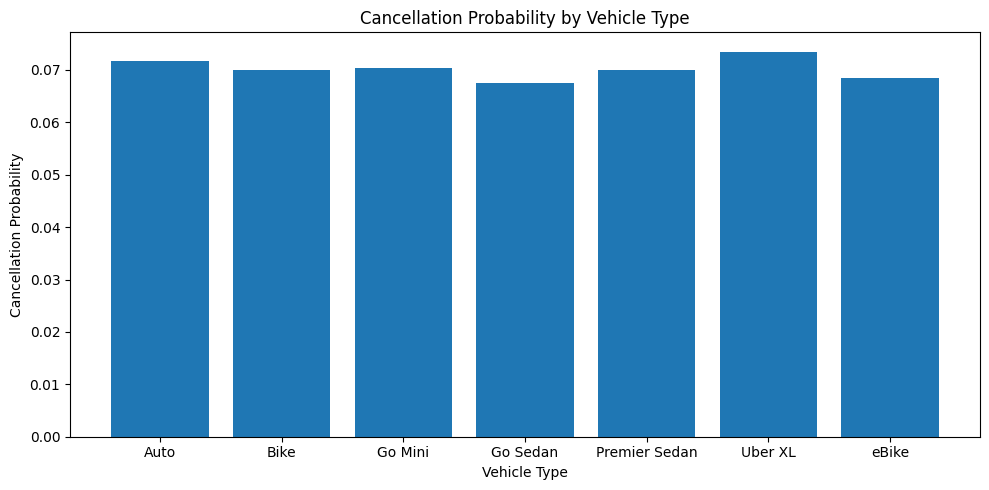

In [3]:
cancellation_probability = df.groupby('Vehicle Type')['is_cancelled'].mean().reset_index()
plt.figure(figsize=(10,5))
plt.bar(cancellation_probability['Vehicle Type'], cancellation_probability['is_cancelled'])
plt.xlabel('Vehicle Type')
plt.ylabel('Cancellation Probability')
plt.title('Cancellation Probability by Vehicle Type')
plt.tight_layout()
plt.show()

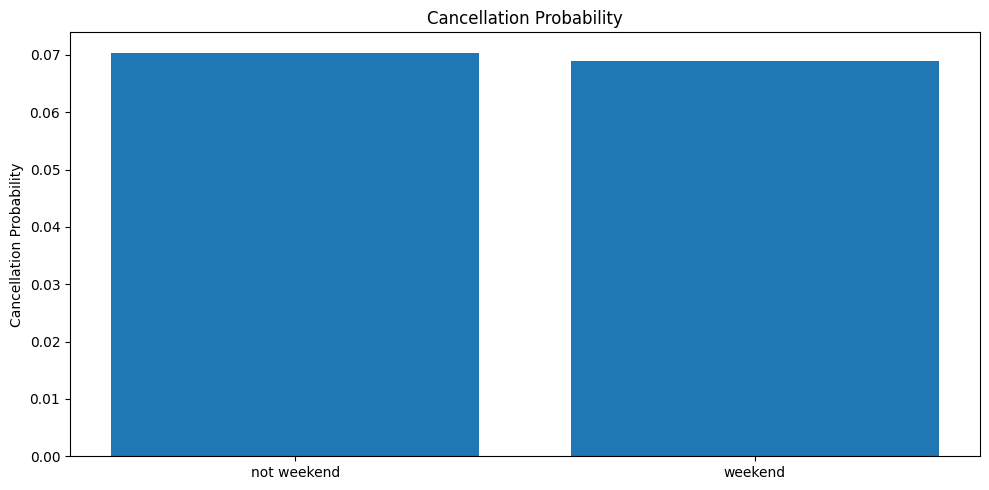

In [21]:
cancellation_probability = df.groupby('is_weekend')['is_cancelled'].mean().reset_index()
plt.figure(figsize=(10,5))
plt.bar(cancellation_probability['is_weekend'].map(lambda x: 'not weekend' if x == 0 else 'weekend'), cancellation_probability['is_cancelled'])
plt.ylabel('Cancellation Probability')
plt.title('Cancellation Probability')
plt.tight_layout()
plt.show()

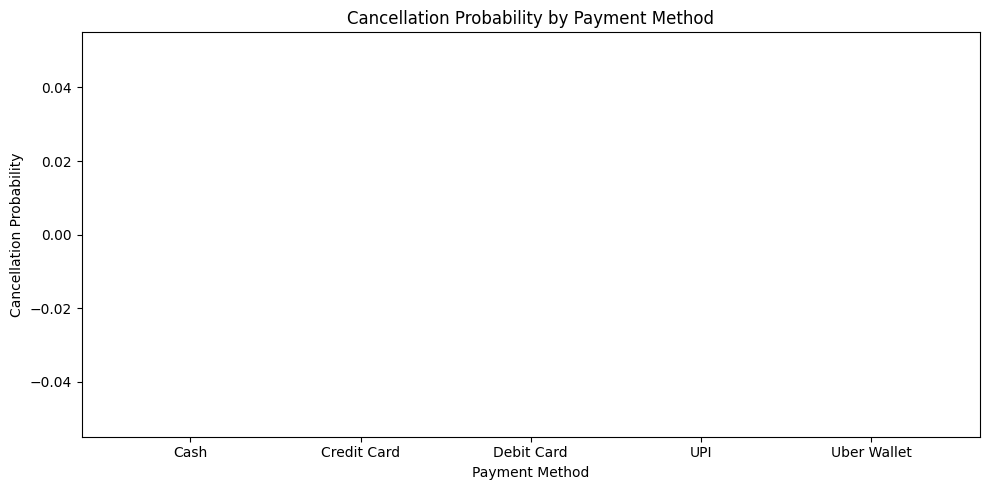

In [5]:
cancellation_probability = df.groupby('Payment Method')['is_cancelled'].mean().reset_index()
plt.figure(figsize=(10,5))
plt.bar(cancellation_probability['Payment Method'], cancellation_probability['is_cancelled'])
plt.xlabel('Payment Method')
plt.ylabel('Cancellation Probability')
plt.title('Cancellation Probability by Payment Method')
plt.tight_layout()
plt.show()

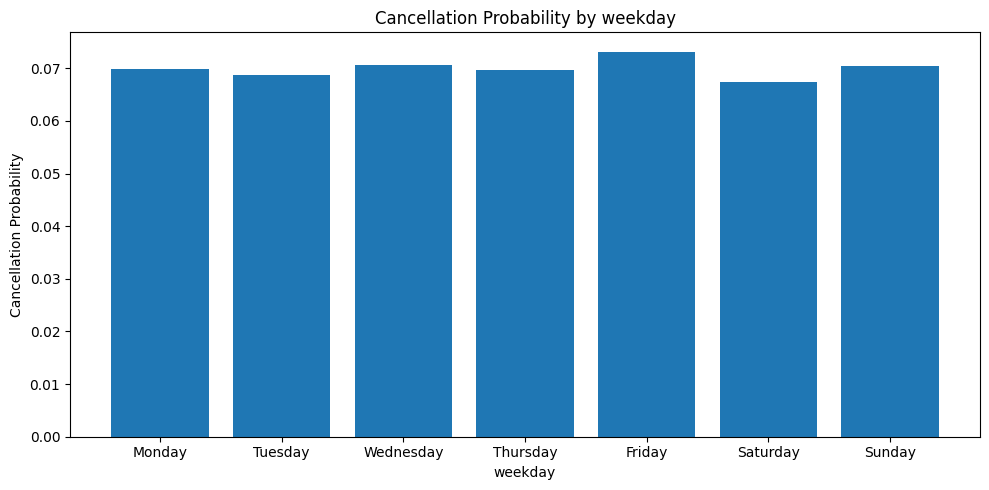

In [23]:
def map_weekday(weekday):
    if weekday == 0:
        return 'Monday'
    elif weekday == 1:
        return 'Tuesday'
    elif weekday == 2:
        return 'Wednesday'
    elif weekday == 3:
        return 'Thursday'
    elif weekday == 4:
        return 'Friday'
    elif weekday == 5:
        return 'Saturday'
    elif weekday == 6:
        return 'Sunday'

cancellation_probability = df.groupby('weekday')['is_cancelled'].mean().reset_index()
plt.figure(figsize=(10,5))
plt.bar(cancellation_probability['weekday'].apply(map_weekday), cancellation_probability['is_cancelled'])
plt.xlabel('weekday')
plt.ylabel('Cancellation Probability')
plt.title('Cancellation Probability by weekday')
plt.tight_layout()
plt.show()

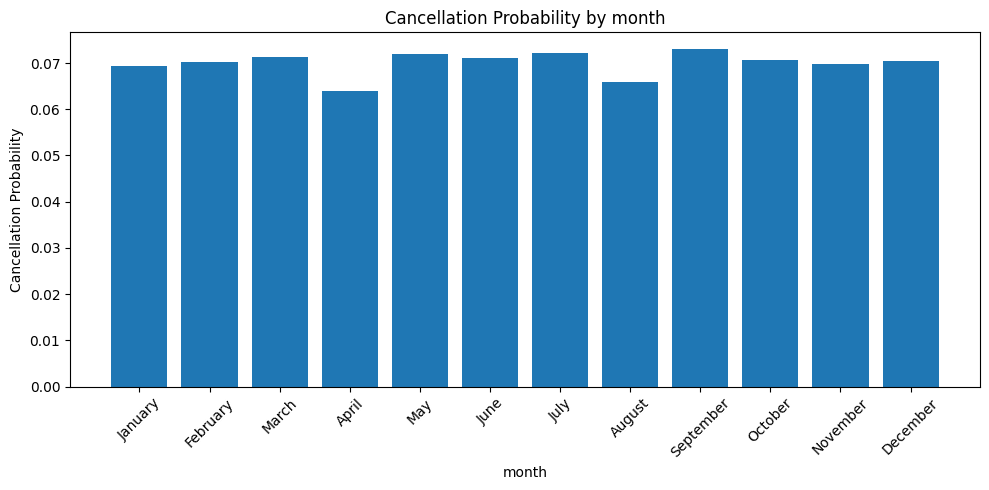

In [25]:
def map_month(month):
    if month == 1:
        return 'January'
    elif month == 2:
        return 'February'
    elif month == 3:
        return 'March'
    elif month == 4:
        return 'April'
    elif month == 5:
        return 'May'
    elif month == 6:
        return 'June'
    elif month == 7:
        return 'July'
    elif month == 8:
        return 'August'
    elif month == 9:
        return 'September'
    elif month == 10:
        return 'October'
    elif month == 11:
        return 'November'
    elif month == 12:
        return 'December'

cancellation_probability = df.groupby('month')['is_cancelled'].mean().reset_index()
plt.figure(figsize=(10,5))
plt.bar(cancellation_probability['month'].apply(map_month), cancellation_probability['is_cancelled'])
plt.xlabel('month')
plt.ylabel('Cancellation Probability')
plt.title('Cancellation Probability by month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
print('total number of cancelled rides:', df['is_cancelled'].sum())
print(f'portion of cancelled rides: {str(100 * np.mean(df['is_cancelled']))}%')

total number of cancelled rides: 10500
portion of cancelled rides: 7.000000000000001%


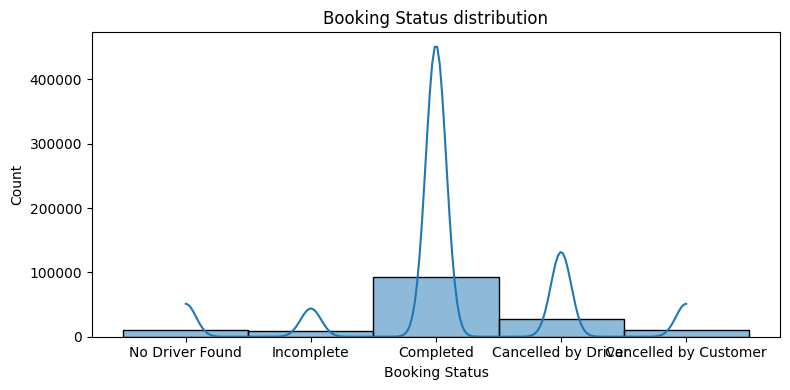

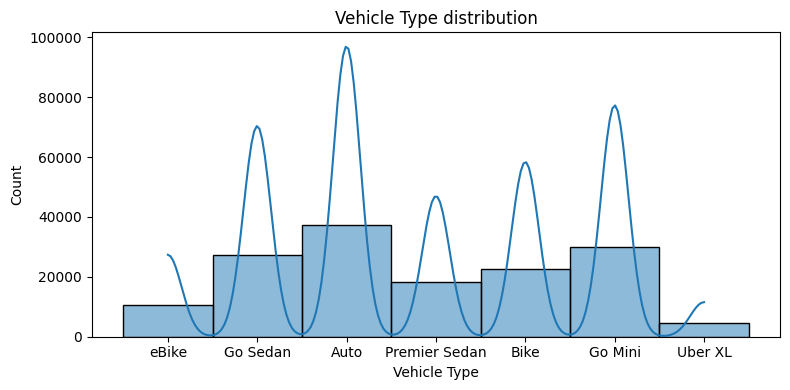

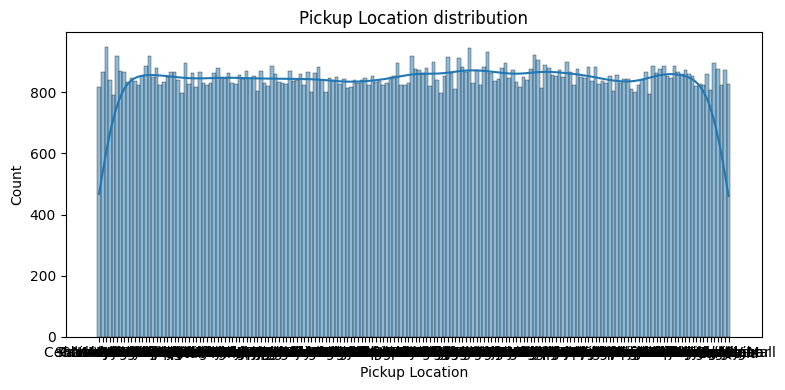

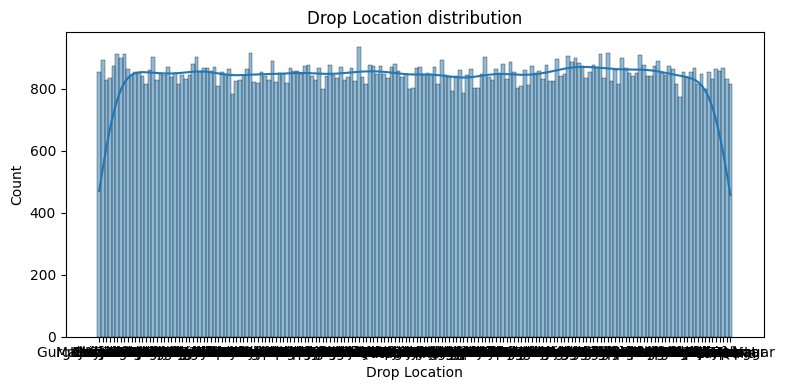

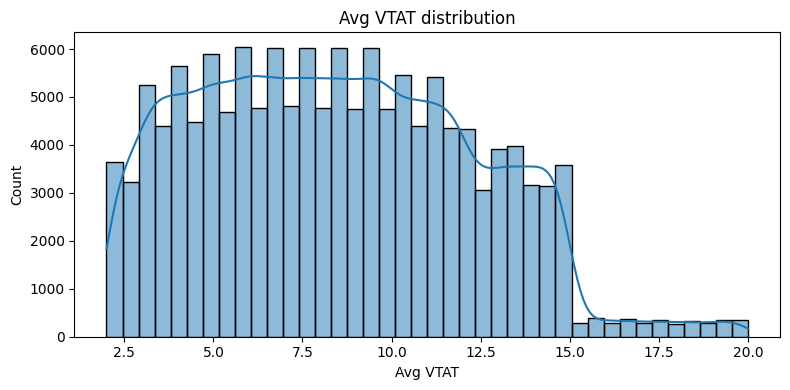

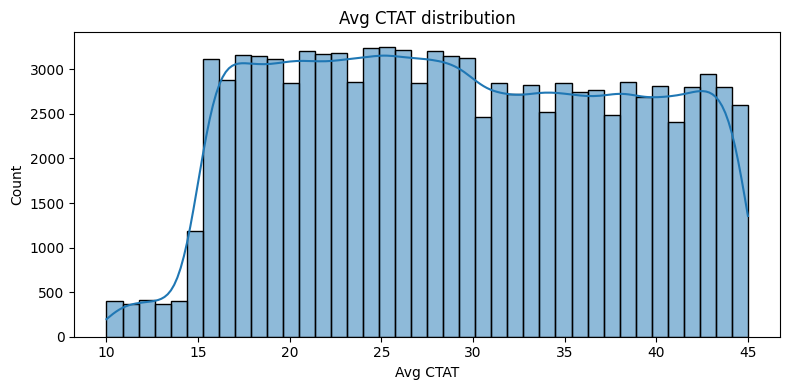

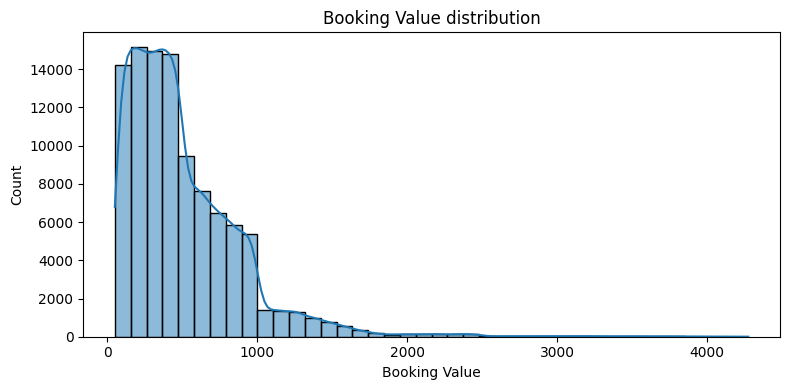

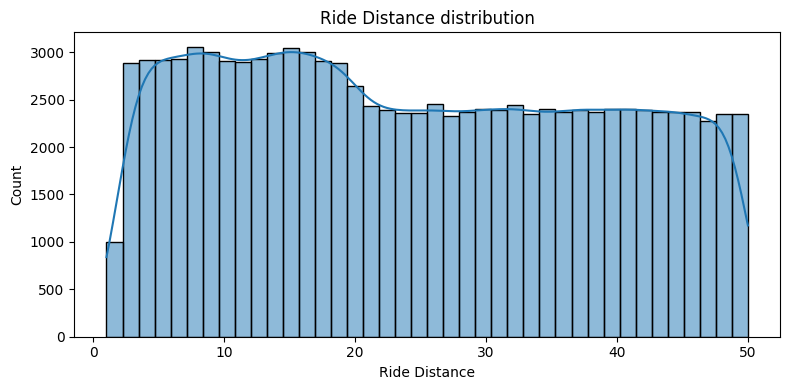

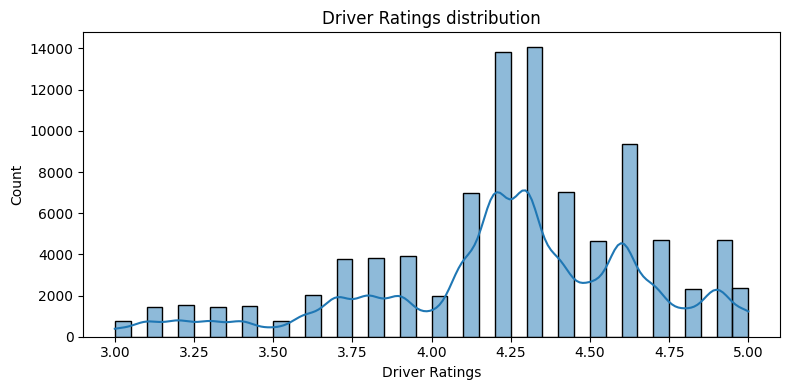

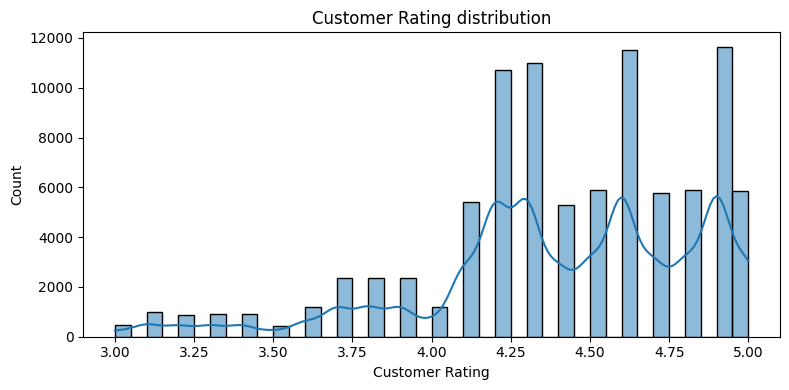

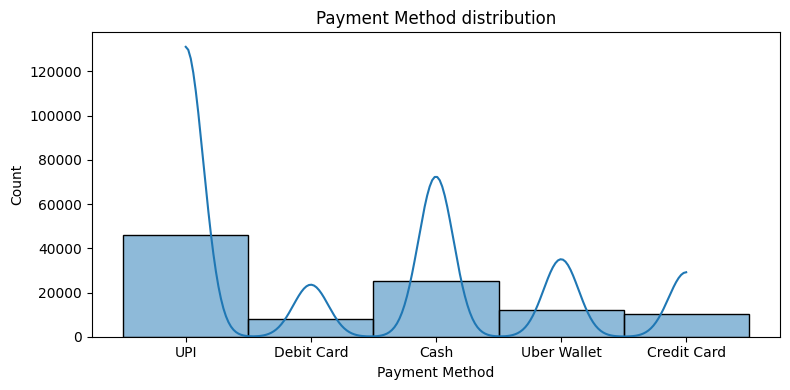

In [49]:
for col in ['Booking Status', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method']:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=40)
    plt.title(f'{col} distribution')
    plt.tight_layout()
    plt.show()

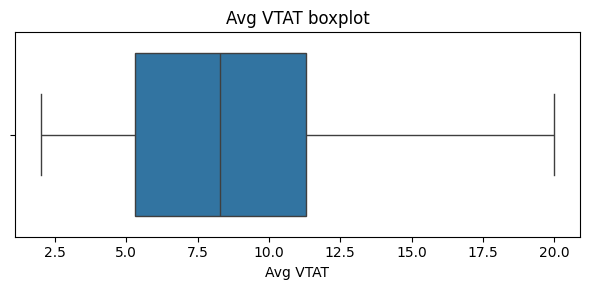

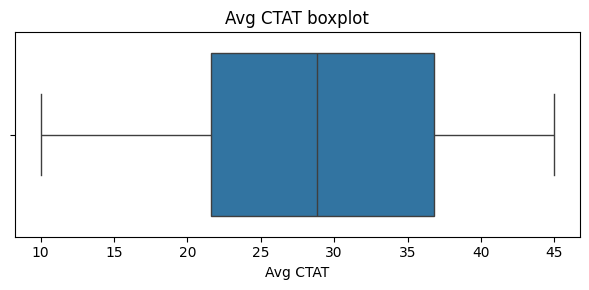

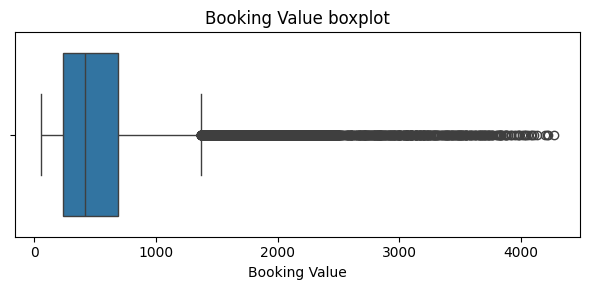

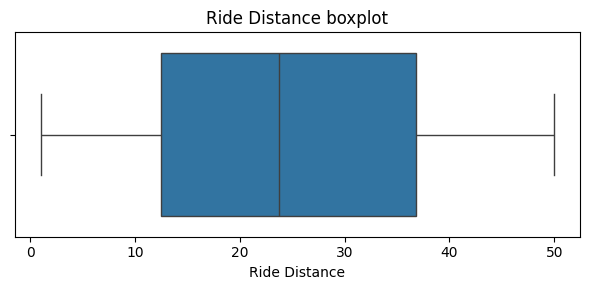

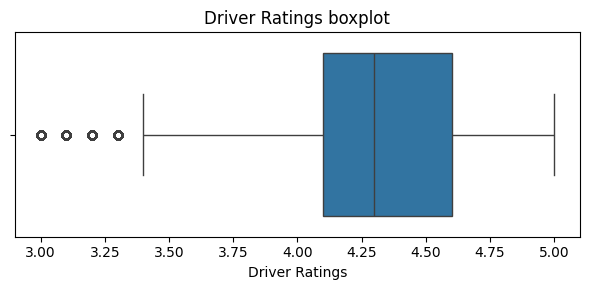

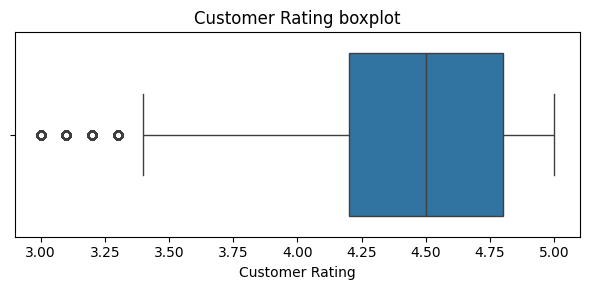

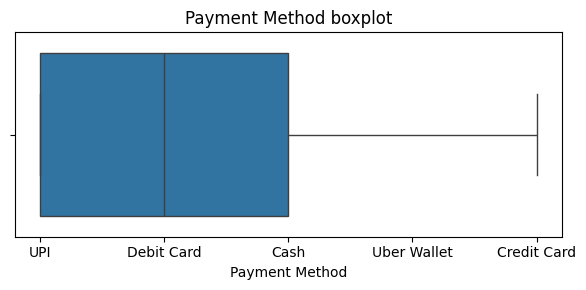

In [50]:
for col in ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method']:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'{col} boxplot')
    plt.tight_layout()
    plt.show()